# Customer Segmentation for Target Marketing

## Importing the libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Reading the data set and setting visual options

In [5]:
#read csv
df = pd.read_csv(r"C:\Users\Sarah\Documents\Data Analysis Project\Retail\retail-data-analysis\data\new_retail_data.csv")
pd.set_option('display.max_columns', None)
pd.set_option('future.no_silent_downcasting', True)
df.head()

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,Age,Gender,Income,Customer_Segment,Date,Year,Month,Time,Total_Purchases,Amount,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788.0,37249.0,Michelle Harrington,Ebony39@gmail.com,1.414787e+09,3959 Amanda Burgs,Dortmund,Berlin,77985.0,Germany,21.0,Male,Low,Regular,9/18/2023,2023.0,September,22:03:55,3.0,108.028757,324.086270,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
1,2174773.0,69749.0,Kelsey Hill,Mark36@gmail.com,6.852900e+09,82072 Dawn Centers,Nottingham,England,99071.0,UK,19.0,Female,Low,Premium,12/31/2023,2023.0,December,8:42:04,2.0,403.353907,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
2,6679610.0,30192.0,Scott Jensen,Shane85@gmail.com,8.362160e+09,4133 Young Canyon,Geelong,New South Wales,75929.0,Australia,48.0,Male,Low,Regular,4/26/2023,2023.0,April,4:06:29,3.0,354.477600,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
3,7232460.0,62101.0,Joseph Miller,Mary34@gmail.com,2.776752e+09,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420.0,Canada,56.0,Male,High,Premium,5/8/2023,2023.0,May,14:55:17,7.0,352.407717,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife
4,4983775.0,27901.0,Debra Coleman,Charles30@gmail.com,9.098268e+09,5813 Lori Ports Suite 269,Bristol,England,48704.0,UK,22.0,Male,Low,Premium,1/10/2024,2024.0,January,16:54:07,2.0,124.276524,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.0,Chocolate cookies


## Cleaning the dataset

In [7]:
#remove duplicates
df = df.drop_duplicates()
df.head()

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,Age,Gender,Income,Customer_Segment,Date,Year,Month,Time,Total_Purchases,Amount,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788.0,37249.0,Michelle Harrington,Ebony39@gmail.com,1.414787e+09,3959 Amanda Burgs,Dortmund,Berlin,77985.0,Germany,21.0,Male,Low,Regular,9/18/2023,2023.0,September,22:03:55,3.0,108.028757,324.086270,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
1,2174773.0,69749.0,Kelsey Hill,Mark36@gmail.com,6.852900e+09,82072 Dawn Centers,Nottingham,England,99071.0,UK,19.0,Female,Low,Premium,12/31/2023,2023.0,December,8:42:04,2.0,403.353907,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
2,6679610.0,30192.0,Scott Jensen,Shane85@gmail.com,8.362160e+09,4133 Young Canyon,Geelong,New South Wales,75929.0,Australia,48.0,Male,Low,Regular,4/26/2023,2023.0,April,4:06:29,3.0,354.477600,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
3,7232460.0,62101.0,Joseph Miller,Mary34@gmail.com,2.776752e+09,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420.0,Canada,56.0,Male,High,Premium,5/8/2023,2023.0,May,14:55:17,7.0,352.407717,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife
4,4983775.0,27901.0,Debra Coleman,Charles30@gmail.com,9.098268e+09,5813 Lori Ports Suite 269,Bristol,England,48704.0,UK,22.0,Male,Low,Premium,1/10/2024,2024.0,January,16:54:07,2.0,124.276524,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.0,Chocolate cookies


In [8]:
#Replace NAN values with empty string
df = df.replace(np.nan, '')

In [9]:
#Convert numeric columns to integer
cols = ['Transaction_ID','Customer_ID','Zipcode','Age','Year','Total_Purchases']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')  
df[cols] = df[cols].fillna(0).astype(np.int64)

In [10]:
df.head()

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,Age,Gender,Income,Customer_Segment,Date,Year,Month,Time,Total_Purchases,Amount,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788,37249,Michelle Harrington,Ebony39@gmail.com,1414786801.0,3959 Amanda Burgs,Dortmund,Berlin,77985,Germany,21,Male,Low,Regular,9/18/2023,2023,September,22:03:55,3,108.028757,324.08627,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
1,2174773,69749,Kelsey Hill,Mark36@gmail.com,6852899987.0,82072 Dawn Centers,Nottingham,England,99071,UK,19,Female,Low,Premium,12/31/2023,2023,December,8:42:04,2,403.353907,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
2,6679610,30192,Scott Jensen,Shane85@gmail.com,8362160449.0,4133 Young Canyon,Geelong,New South Wales,75929,Australia,48,Male,Low,Regular,4/26/2023,2023,April,4:06:29,3,354.4776,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
3,7232460,62101,Joseph Miller,Mary34@gmail.com,2776751724.0,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420,Canada,56,Male,High,Premium,5/8/2023,2023,May,14:55:17,7,352.407717,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife
4,4983775,27901,Debra Coleman,Charles30@gmail.com,9098267635.0,5813 Lori Ports Suite 269,Bristol,England,48704,UK,22,Male,Low,Premium,1/10/2024,2024,January,16:54:07,2,124.276524,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.0,Chocolate cookies


In [11]:
#Format Phone number to a standard form
df['Phone']=df['Phone'].apply(lambda x: str(x))
df['Phone']= df['Phone'].apply(lambda x: x[0:3]+'-'+x[3:6]+'-'+x[6:10])
df.head()

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,Age,Gender,Income,Customer_Segment,Date,Year,Month,Time,Total_Purchases,Amount,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788,37249,Michelle Harrington,Ebony39@gmail.com,141-478-6801,3959 Amanda Burgs,Dortmund,Berlin,77985,Germany,21,Male,Low,Regular,9/18/2023,2023,September,22:03:55,3,108.028757,324.08627,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
1,2174773,69749,Kelsey Hill,Mark36@gmail.com,685-289-9987,82072 Dawn Centers,Nottingham,England,99071,UK,19,Female,Low,Premium,12/31/2023,2023,December,8:42:04,2,403.353907,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
2,6679610,30192,Scott Jensen,Shane85@gmail.com,836-216-0449,4133 Young Canyon,Geelong,New South Wales,75929,Australia,48,Male,Low,Regular,4/26/2023,2023,April,4:06:29,3,354.4776,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
3,7232460,62101,Joseph Miller,Mary34@gmail.com,277-675-1724,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420,Canada,56,Male,High,Premium,5/8/2023,2023,May,14:55:17,7,352.407717,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife
4,4983775,27901,Debra Coleman,Charles30@gmail.com,909-826-7635,5813 Lori Ports Suite 269,Bristol,England,48704,UK,22,Male,Low,Premium,1/10/2024,2024,January,16:54:07,2,124.276524,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.0,Chocolate cookies


In [12]:
# Convert object column to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Format the date as day-month-year
df['Date'] = df['Date'].dt.strftime('%d-%m-%Y')

df.head()

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,Age,Gender,Income,Customer_Segment,Date,Year,Month,Time,Total_Purchases,Amount,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788,37249,Michelle Harrington,Ebony39@gmail.com,141-478-6801,3959 Amanda Burgs,Dortmund,Berlin,77985,Germany,21,Male,Low,Regular,18-09-2023,2023,September,22:03:55,3,108.028757,324.08627,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
1,2174773,69749,Kelsey Hill,Mark36@gmail.com,685-289-9987,82072 Dawn Centers,Nottingham,England,99071,UK,19,Female,Low,Premium,31-12-2023,2023,December,8:42:04,2,403.353907,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
2,6679610,30192,Scott Jensen,Shane85@gmail.com,836-216-0449,4133 Young Canyon,Geelong,New South Wales,75929,Australia,48,Male,Low,Regular,26-04-2023,2023,April,4:06:29,3,354.4776,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
3,7232460,62101,Joseph Miller,Mary34@gmail.com,277-675-1724,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420,Canada,56,Male,High,Premium,08-05-2023,2023,May,14:55:17,7,352.407717,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife
4,4983775,27901,Debra Coleman,Charles30@gmail.com,909-826-7635,5813 Lori Ports Suite 269,Bristol,England,48704,UK,22,Male,Low,Premium,10-01-2024,2024,January,16:54:07,2,124.276524,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.0,Chocolate cookies


In [13]:
# Convert object column to datetime
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

# Format time to show hours and minutes only
df['Time'] = df['Time'].dt.strftime('%H:%M')

df.head()

C:\Users\Sarah\AppData\Local\Temp\ipykernel_7736\483160429.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'], errors='coerce')


,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,Age,Gender,Income,Customer_Segment,Date,Year,Month,Time,Total_Purchases,Amount,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788,37249,Michelle Harrington,Ebony39@gmail.com,141-478-6801,3959 Amanda Burgs,Dortmund,Berlin,77985,Germany,21,Male,Low,Regular,18-09-2023,2023,September,22:03,3,108.028757,324.08627,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
1,2174773,69749,Kelsey Hill,Mark36@gmail.com,685-289-9987,82072 Dawn Centers,Nottingham,England,99071,UK,19,Female,Low,Premium,31-12-2023,2023,December,08:42,2,403.353907,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
2,6679610,30192,Scott Jensen,Shane85@gmail.com,836-216-0449,4133 Young Canyon,Geelong,New South Wales,75929,Australia,48,Male,Low,Regular,26-04-2023,2023,April,04:06,3,354.4776,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
3,7232460,62101,Joseph Miller,Mary34@gmail.com,277-675-1724,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420,Canada,56,Male,High,Premium,08-05-2023,2023,May,14:55,7,352.407717,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife
4,4983775,27901,Debra Coleman,Charles30@gmail.com,909-826-7635,5813 Lori Ports Suite 269,Bristol,England,48704,UK,22,Male,Low,Premium,10-01-2024,2024,January,16:54,2,124.276524,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.0,Chocolate cookies


In [14]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [15]:
df.head()

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,Age,Gender,Income,Customer_Segment,Date,Year,Month,Time,Total_Purchases,Amount,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788,37249,Michelle Harrington,Ebony39@gmail.com,141-478-6801,3959 Amanda Burgs,Dortmund,Berlin,77985,Germany,21,Male,Low,Regular,18-09-2023,2023,September,22:03,3,108.03,324.09,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.00,Cycling shorts
1,2174773,69749,Kelsey Hill,Mark36@gmail.com,685-289-9987,82072 Dawn Centers,Nottingham,England,99071,UK,19,Female,Low,Premium,31-12-2023,2023,December,08:42,2,403.35,806.71,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.00,Lenovo Tab
2,6679610,30192,Scott Jensen,Shane85@gmail.com,836-216-0449,4133 Young Canyon,Geelong,New South Wales,75929,Australia,48,Male,Low,Regular,26-04-2023,2023,April,04:06,3,354.48,1063.43,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.00,Sports equipment
3,7232460,62101,Joseph Miller,Mary34@gmail.com,277-675-1724,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420,Canada,56,Male,High,Premium,08-05-2023,2023,May,14:55,7,352.41,2466.85,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.00,Utility knife
4,4983775,27901,Debra Coleman,Charles30@gmail.com,909-826-7635,5813 Lori Ports Suite 269,Bristol,England,48704,UK,22,Male,Low,Premium,10-01-2024,2024,January,16:54,2,124.28,248.55,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.00,Chocolate cookies


In [16]:
df['Age'] = df['Age'].replace('', pd.NA)
df['Total_Amount'] = df['Total_Amount'].replace('', pd.NA)
df['Total_Purchases'] = df['Total_Purchases'].replace('', pd.NA)

# Convert columns to numeric, forcing non-convertible values to NaN
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Total_Amount'] = pd.to_numeric(df['Total_Amount'], errors='coerce')
df['Total_Purchases'] = pd.to_numeric(df['Total_Purchases'], errors='coerce')

# Check for NaN values in the DataFrame
print(df.isnull().sum())

Transaction_ID        0
Customer_ID           0
Name                  0
Email                 0
Phone                 0
Address               0
City                  0
State                 0
Zipcode               0
Country               0
Age                   0
Gender                0
Income                0
Customer_Segment      0
Date                359
Year                  0
Month                 0
Time                350
Total_Purchases       0
Amount                0
Total_Amount        350
Product_Category      0
Product_Brand         0
Product_Type          0
Feedback              0
Shipping_Method       0
Payment_Method        0
Order_Status          0
Ratings               0
products              0
dtype: int64


In [17]:
df['Amount'] = df['Amount'].replace('',0)
df['Total_Amount'] = df['Total_Amount'].fillna(df['Total_Purchases']*df['Amount'])
df['Date'] = df['Date'].fillna('')
df['Time'] = df['Time'].fillna('')
pd.set_option('future.no_silent_downcasting', True)

In [18]:
df['Total_Amount'] = pd.to_numeric(df['Total_Amount'], errors='coerce')

## New Dataframe for Customer Segmentation

In [20]:
# declaring new dataframe with customer segmentation
customer_segment = df[['Age', 'Gender','Income', 'Total_Purchases','Total_Amount']]
customer_segment.head(10)

,Age,Gender,Income,Total_Purchases,Total_Amount
0,21,Male,Low,3,324.09
1,19,Female,Low,2,806.71
2,48,Male,Low,3,1063.43
3,56,Male,High,7,2466.85
4,22,Male,Low,2,248.55
5,58,Female,Medium,4,1185.17
6,29,Female,Low,2,630.12
7,29,Male,Medium,1,46.59
8,46,Male,Medium,8,2630.71
9,25,Male,Medium,10,3976.11


In [21]:
# Customer segments are defined based on pre-defined threshold
mean = customer_segment["Total_Amount"].mean()
customer_segment.insert(5,"High_Spender",["Y" if x > mean else "N" for x in customer_segment["Total_Amount"]],False)

In [22]:
customer_segment.head(10)

,Age,Gender,Income,Total_Purchases,Total_Amount,High_Spender
0,21,Male,Low,3,324.09,N
1,19,Female,Low,2,806.71,N
2,48,Male,Low,3,1063.43,N
3,56,Male,High,7,2466.85,Y
4,22,Male,Low,2,248.55,N
5,58,Female,Medium,4,1185.17,N
6,29,Female,Low,2,630.12,N
7,29,Male,Medium,1,46.59,N
8,46,Male,Medium,8,2630.71,Y
9,25,Male,Medium,10,3976.11,Y


In [23]:
bins = [0, 18, 30, 40, 50, 60, 100]  
labels = ['0-18', '19-30', '31-40', '41-50', '51-60', '61+']

# Creating a new column 'Age Group' with bins
age_group = pd.cut(customer_segment['Age'], bins=bins, labels=labels, right=False)
customer_segment.insert(1, "Age_Group", age_group, False)

In [24]:
customer_segment.head()

,Age,Age_Group,Gender,Income,Total_Purchases,Total_Amount,High_Spender
0,21,19-30,Male,Low,3,324.09,N
1,19,19-30,Female,Low,2,806.71,N
2,48,41-50,Male,Low,3,1063.43,N
3,56,51-60,Male,High,7,2466.85,Y
4,22,19-30,Male,Low,2,248.55,N


In [42]:
# Remove rows where Income is NaN or blank
customer_segment = customer_segment[customer_segment['Income'].notna()]
customer_segment = customer_segment[customer_segment['Income'] != ""]  # Remove blank strings

# Ensure Income is categorical and remove unused categories
if customer_segment['Income'].dtype.name == 'category':
    customer_segment['Income'] = customer_segment['Income'].cat.remove_unused_categories()

# Filter only high spenders
high_spenders = customer_segment[customer_segment['High_Spender'] == 'Y']

# Get Income levels that actually have high spenders
valid_income_levels = high_spenders['Income'].unique()
high_spenders = high_spenders[high_spenders['Income'].isin(valid_income_levels)]

## Visualisations

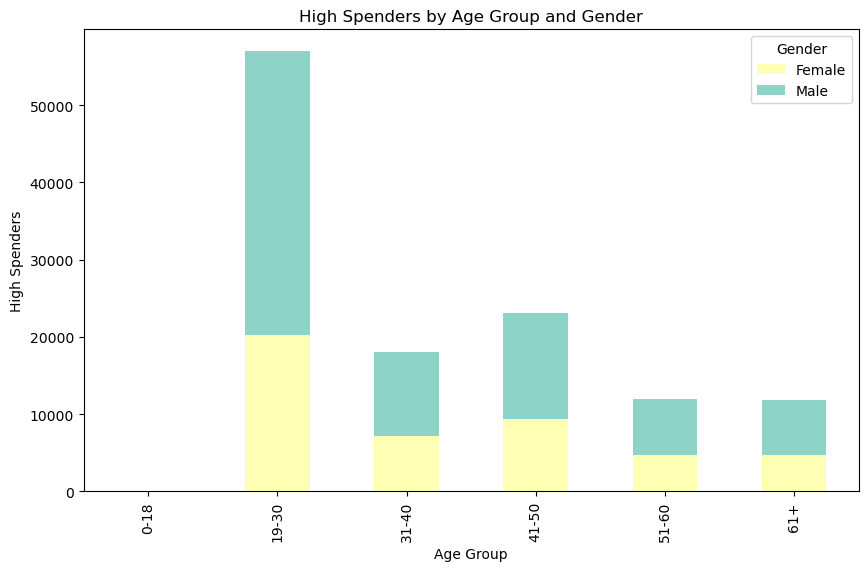

In [45]:
# Group by 'Age Group' and 'Gender' and count High Spenders
stacked_data = customer_segment[customer_segment['High_Spender'] == 'Y'].groupby(['Age_Group', 'Gender'], observed=True).size().unstack(fill_value=0)

# Plot
stacked_data.plot(kind='bar', stacked=True, color=['#8dd3c7', '#ffffb3'], figsize=(10, 6))
plt.title("High Spenders by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("High Spenders")
plt.legend(title="Gender")
plt.show()

C:\Users\Sarah\Anaconda\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\Sarah\Anaconda\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


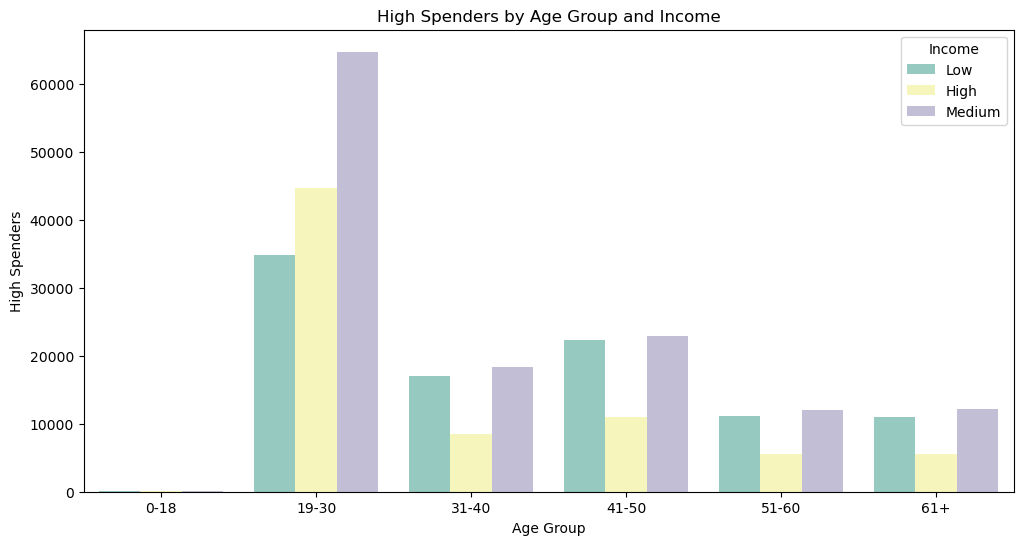

In [47]:
plt.figure(figsize=(12, 6))
sns.countplot(data=customer_segment, x='Age_Group', hue='Income', palette='Set3')
plt.title('High Spenders by Age Group and Income')
plt.xlabel('Age Group')
plt.ylabel('High Spenders')
plt.legend(title='Income')
plt.show()

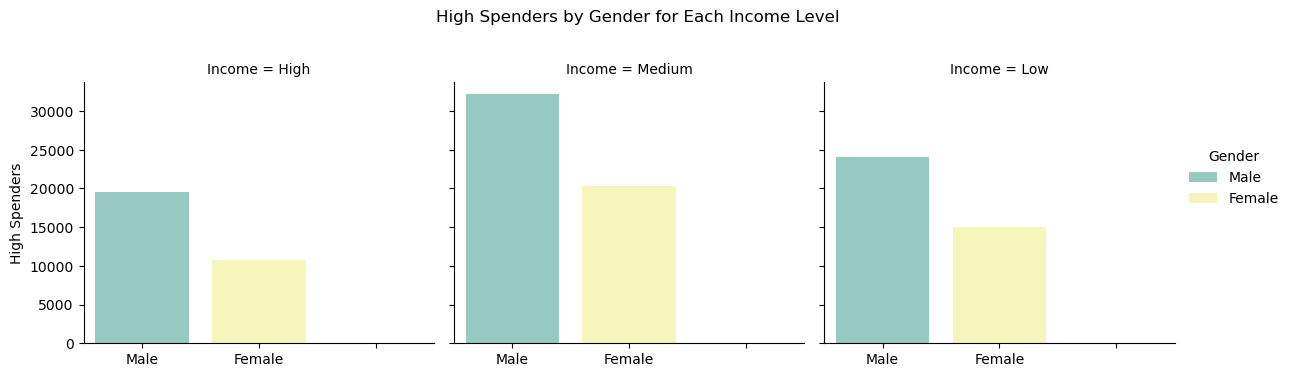

In [49]:
# Create FacetGrid
g = sns.FacetGrid(high_spenders, col='Income', hue='Gender', height=4, aspect=1, palette='Set3')
g.map(sns.countplot, 'Gender', order=high_spenders['Gender'].unique())

g.add_legend()
g.set_axis_labels("", "High Spenders")
plt.subplots_adjust(top=0.8)
g.fig.suptitle('High Spenders by Gender for Each Income Level')
plt.show()


In [51]:
customer_segment.to_csv('customer-segmentation.csv',index=False)